In [1]:
import pandas as pd
import numpy as np
import polars as pl
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Dendogram and VIF- Full cost basis

In [4]:
ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
TRAIN_PATH = RAW_DIR / "train.parquet"

In [5]:
train = pl.read_parquet(TRAIN_PATH)

In [6]:
full_cost_basis = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("cost_basis_"))
    .collect()
)
len(full_cost_basis)
full_cost_basis_df = full_cost_basis.to_pandas()

In [7]:
full_cost_basis_df = full_cost_basis_df.pivot(columns='metric',index='day_utc', values='value')

In [8]:
X = (
    full_cost_basis_df
    .select_dtypes(include='number')
    .replace([np.inf, -np.inf], np.nan)
)
X = X.fillna(X.median())
X = X.loc[:, X.nunique() > 1]

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    index=X.index,
    columns=X.columns
)

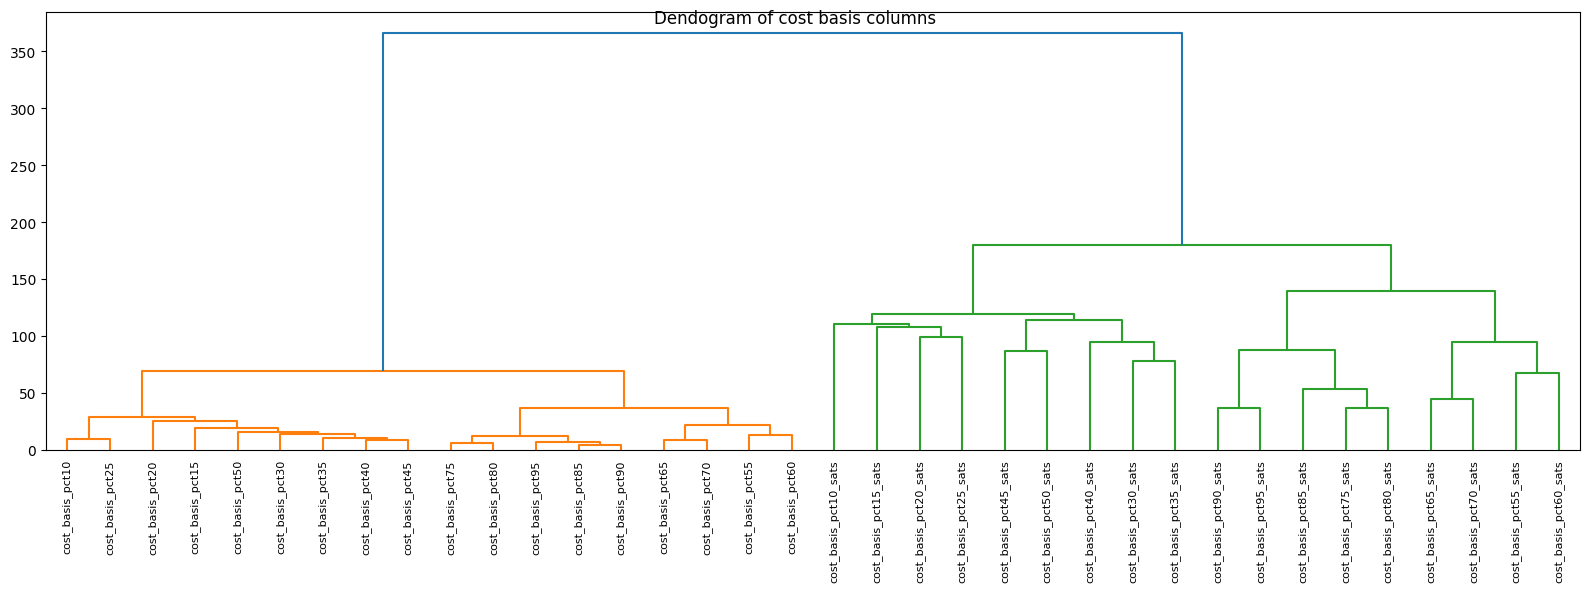

In [9]:
Z = linkage(X_scaled.T, method="ward", metric="euclidean")

fig = plt.figure(figsize=(16, 6))
dendrogram(
    Z,
    labels=X_scaled.columns,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.tight_layout()
fig.suptitle("Dendogram of cost basis columns")
plt.show()

In [10]:
clusters_cost = fcluster(Z, t=5, criterion="maxclust")

cluster_map_cost = dict(zip(X_scaled.columns, clusters_cost))

cluster_df_cost = pd.DataFrame({
    "feature": X_scaled.columns,
    "cluster": clusters_cost
})
cluster_df_cost.head()

,feature,cluster
0,cost_basis_pct10,1
1,cost_basis_pct10_sats,2
2,cost_basis_pct15,1
3,cost_basis_pct15_sats,2
4,cost_basis_pct20,1


In [11]:
n = cluster_df_cost["cluster"].nunique()
clusters = {}
for i in range(1, n+1):
    clusters[i] = cluster_df_cost[cluster_df_cost["cluster"] == i]["feature"].tolist()

In [12]:
high_vif = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif[i]}")


Cluster 1:
cost_basis_pct90    3340.302751
cost_basis_pct85    3136.013152
cost_basis_pct95    2304.347034
cost_basis_pct75     858.957195
cost_basis_pct80     794.469413
cost_basis_pct70     549.128335
cost_basis_pct35     470.501486
cost_basis_pct65     421.481814
cost_basis_pct60     373.742085
cost_basis_pct40     372.222952
cost_basis_pct25     354.360684
cost_basis_pct10     338.903969
cost_basis_pct45     317.428026
cost_basis_pct50     282.638424
cost_basis_pct55     259.721912
cost_basis_pct30     241.250626
cost_basis_pct20     209.689172
cost_basis_pct15     116.356658

  High VIF cols (>10): ['cost_basis_pct10', 'cost_basis_pct15', 'cost_basis_pct20', 'cost_basis_pct25', 'cost_basis_pct30', 'cost_basis_pct35', 'cost_basis_pct40', 'cost_basis_pct45', 'cost_basis_pct50', 'cost_basis_pct55', 'cost_basis_pct60', 'cost_basis_pct65', 'cost_basis_pct70', 'cost_basis_pct75', 'cost_basis_pct80', 'cost_basis_pct85', 'cost_basis_pct90', 'cost_basis_pct95']

Cluster 2:
cost_basis_pct2

In [13]:
all_high_vif_cost_basis = [col for cols in high_vif.values() for col in cols]

In [14]:
cluster_df_cost["cluster"].value_counts().sort_index()

cluster
1    18
2     4
3     5
4     5
5     4
Name: count, dtype: int64

# Dendogram and VIF - Address Columns

In [15]:
full_address = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("addrs"))
    .collect()
)
len(full_address)
full_address_pd = full_address.to_pandas()

In [16]:
full_address_df = full_address_pd.pivot(columns='metric',index='day_utc', values='value')

In [17]:
X = (
    full_address_df
    .select_dtypes(include='number')
    .replace([np.inf, -np.inf], np.nan)
)
X = X.fillna(X.median())
X = X.loc[:, X.nunique() > 1]

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    index=X.index,
    columns=X.columns
)

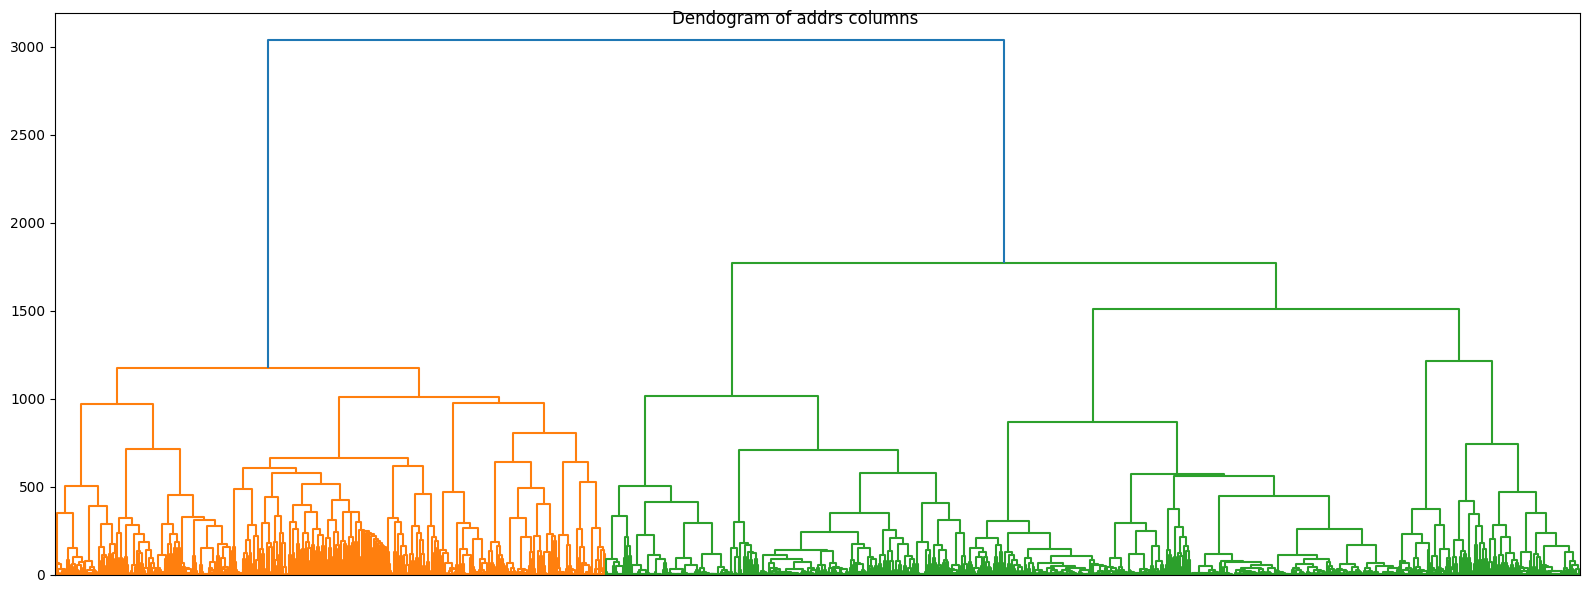

In [18]:
Z = linkage(X_scaled.T, method="ward", metric="euclidean")

fig = plt.figure(figsize=(16, 6))
dendrogram(
    Z,
    no_labels=True
)

plt.tight_layout()
fig.suptitle("Dendogram of addrs columns")
plt.show()

In [19]:
clusters_addrs = fcluster(Z, t=5, criterion="maxclust")

cluster_map_addrs = dict(zip(X_scaled.columns, clusters_addrs))


cluster_df_addrs = pd.DataFrame({
    "feature": X_scaled.columns,
    "cluster": clusters_addrs
})
cluster_df_addrs.head()

,feature,cluster
0,addrs_above_100btc_under_1k_btc__30d_change,1
1,addrs_above_100btc_under_1k_btc__30d_change_btc,1
2,addrs_above_100btc_under_1k_btc__30d_change_usd,1
3,addrs_above_100btc_under_1k_btc_addr_count,5
4,addrs_above_100btc_under_1k_btc_addr_count_30d...,1


In [20]:
cluster_df_addrs["cluster"].value_counts().sort_index()

cluster
1    1830
2    1207
3    1429
4     174
5     429
Name: count, dtype: int64

In [21]:
n = cluster_df_addrs["cluster"].nunique()
clusters_addrs_dict = {}
for i in range(1, n+1):
    clusters_addrs_dict[i] = cluster_df_addrs[cluster_df_addrs["cluster"] == i]["feature"].tolist()


high_vif_addrs = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters_addrs_dict[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif_addrs[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif_addrs[i]}")


Cluster 1:


/Users/nguyenuyennguyen/Miniforge3-Darwin-arm64/envs/adaptivesats/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/nguyenuyennguyen/Miniforge3-Darwin-arm64/envs/adaptivesats/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


addrs_above_100btc_under_1k_btc__30d_change                                                       0.0
addrs_over_1sat_net_realized_pnl_rel_to_realized_cap                                              0.0
addrs_over_1sat_max_cost_basis_sats                                                               0.0
addrs_over_1sat_mvrv                                                                              0.0
addrs_over_1sat_neg_realized_loss                                                                 0.0
addrs_over_1sat_neg_realized_loss_cumulative                                                      0.0
addrs_over_1sat_neg_unrealized_loss                                                               0.0
addrs_over_1sat_neg_unrealized_loss_rel_to_market_cap                                             0.0
addrs_over_1sat_net_realized_pnl                                                                  0.0
addrs_over_1sat_net_realized_pnl_7d_ema                                           

/Users/nguyenuyennguyen/Miniforge3-Darwin-arm64/envs/adaptivesats/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


KeyboardInterrupt: 

In [ ]:
all_high_vif_addrs = [col for cols in high_vif_addrs.values() for col in cols]

# Dendogram and VIF - DCA Strategy

In [ ]:
full_dca_family = (
    pl.scan_parquet("../data/raw/train.parquet")
    .filter(pl.col("metric").str.contains("dca_"))
    .collect()
)

full_dca_df = full_dca_family.to_pandas()

In [ ]:
full_dca_df = full_dca_df.pivot(columns='metric',index='day_utc', values='value')
len(full_dca_df.columns)

In [ ]:
X = (
    full_dca_df
    .select_dtypes(include='number')
    .replace([np.inf, -np.inf], np.nan)
)
X = X.fillna(X.median())
X = X.loc[:, X.nunique() > 1]

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    index=X.index,
    columns=X.columns
)

In [ ]:
Z = linkage(X_scaled.T, method="ward", metric="euclidean")

fig = plt.figure(figsize=(16, 6))
dendrogram(
    Z,
    no_labels=True
)

plt.tight_layout()
fig.suptitle("Dendogram of dca columns")
plt.axhline(y=200, c='k', linestyle='--', linewidth=2) 
plt.show()

In [ ]:
clusters_dca = fcluster(Z, t=13, criterion="maxclust")

cluster_map_dca = dict(zip(X_scaled.columns, clusters_dca))


cluster_df_dca = pd.DataFrame({
    "feature": X_scaled.columns,
    "cluster": clusters_dca
})
cluster_df_dca.head()

In [ ]:
cluster_df_dca["cluster"].value_counts().sort_index()

In [ ]:
n = cluster_df_dca["cluster"].nunique()
clusters_dca_dict = {}
for i in range(1, n+1):
    clusters_dca_dict[i] = cluster_df_dca[cluster_df_dca["cluster"] == i]["feature"].tolist()


high_vif_dca = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters_dca_dict[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif_dca[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif_dca[i]}")

In [ ]:
all_high_vif_dca = [col for cols in high_vif_dca.values() for col in cols]
len(all_high_vif_dca)

# Dendogram and VIF - Price

In [26]:
full_price = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("price_"))
    .collect()
)
len(full_price)
full_price_df = full_price.to_pandas()

In [28]:
full_price_df

,day_utc,metric,value
0,2019-01-06,price_10y_ago,0.0
1,2019-01-07,price_10y_ago,0.0
2,2019-01-08,price_10y_ago,0.0
3,2019-01-09,price_10y_ago,0.0
4,2019-01-10,price_10y_ago,0.0
...,...,...,...
27048986,2023-12-27,price_true_range_2w_sum,19711.3
27048987,2023-12-28,price_true_range_2w_sum,19175.3
27048988,2023-12-29,price_true_range_2w_sum,19617.1
27048989,2023-12-30,price_true_range_2w_sum,19627.1


In [29]:
full_price_df = full_price_df.pivot(columns='metric',index='day_utc', values='value')
len(full_price_df.columns)

6050

In [30]:
X = (
    full_price_df
    .select_dtypes(include='number')
    .replace([np.inf, -np.inf], np.nan)
)
X = X.fillna(X.median())
X = X.loc[:, X.nunique() > 1]

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    index=X.index,
    columns=X.columns
)

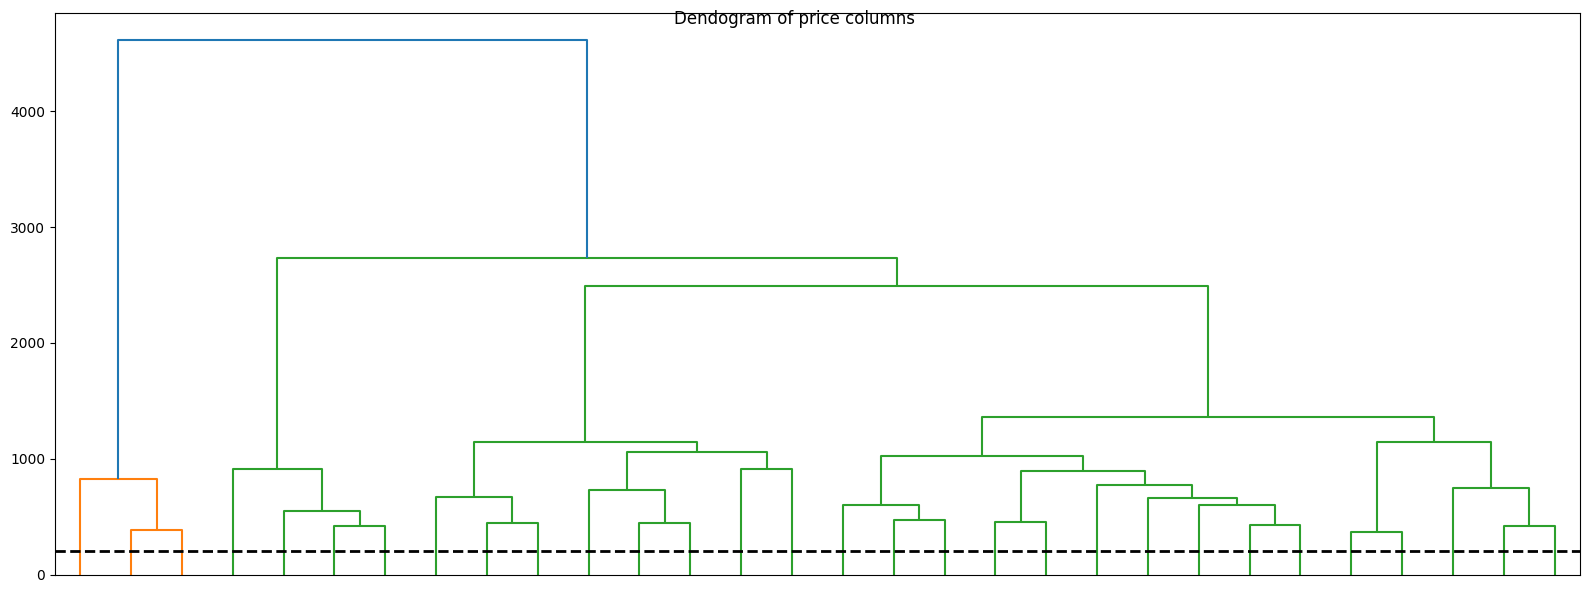

In [35]:
Z = linkage(X_scaled.T, method="ward", metric="euclidean")

fig = plt.figure(figsize=(16, 6))

dendrogram(
    Z,
    no_labels=True,
    truncate_mode='lastp', p=30, leaf_rotation=90
)

plt.tight_layout()
fig.suptitle("Dendogram of price columns")
plt.axhline(y=200, c='k', linestyle='--', linewidth=2) 
plt.show()

In [36]:
clusters_price = fcluster(Z, t=5, criterion="maxclust")

cluster_map_price = dict(zip(X_scaled.columns, clusters_price))


cluster_df_price = pd.DataFrame({
    "feature": X_scaled.columns,
    "cluster": clusters_price
})
cluster_df_price.head()

,feature,cluster
0,price_10y_ago,4
1,price_10y_ago_sats,4
2,price_111d_sma,1
3,price_111d_sma_ratio,5
4,price_111d_sma_ratio_0sd_usd,1


In [37]:
cluster_df_price["cluster"].value_counts().sort_index()

cluster
1    1709
2    1642
3    1409
4     910
5     380
Name: count, dtype: int64

In [ ]:
n = cluster_df_price["cluster"].nunique()
clusters_price_dict = {}
for i in range(1, n+1):
    clusters_price_dict[i] = cluster_df_price[cluster_df_price["cluster"] == i]["feature"].tolist()


high_vif_addrs = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters_price_dict[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif_price[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif_price[i]}")

In [ ]:
all_high_vif_price = [col for cols in high_vif_price.values() for col in cols]
len(all_high_vif_price)

# 0 variance columns

In [45]:
import polars as pl
from pathlib import Path

def main():
    train_path = Path("../data/raw/train.parquet")
    output_path = Path("../common_zero_var_cols.csv")  # saved to project root

    print("Reading train.parquet...")
    df = pl.read_parquet(train_path)
    print(f"Shape: {df.shape}")

    print("Computing zero-variance metrics...")
    zero_var = (
        df.group_by("metric")
        .agg(pl.col("value").n_unique().alias("n_unique"))
        .filter(pl.col("n_unique") == 1)
        .select("metric")
        .sort("metric")
    )

    print(f"Zero-variance metrics found: {len(zero_var)}")

    zero_var.write_csv(output_path)
    print(f"Saved to {output_path}")

main()

Reading train.parquet...
Shape: (203205223, 3)
Computing zero-variance metrics...
Zero-variance metrics found: 2810
Saved to ../common_zero_var_cols.csv


In [56]:
import polars as pl
import pandas as pd

# load zero-var column names from CSV
constant_cols = pd.read_csv('../common_zero_var_cols.csv')['metric'].tolist()

# read and filter to only zero-var metrics (cheaper to pivot a subset)
df_check_variance = pl.read_parquet('../data/raw/train.parquet')
df_check_variance_filtered = df_check_variance.filter(pl.col('metric').is_in(constant_cols))

# pivot to wide format
df_check_variance_filtered_wide = (
    df_check_variance_filtered
    .pivot(index='day_utc', on='metric', values='value')
    .sort('day_utc')
)

# check which columns are strictly zero (min==0 AND max==0)
df_var_pd = df_check_variance_filtered_wide.drop('day_utc').to_pandas()
is_strictly_zero = (df_var_pd.max() == 0) & (df_var_pd.min() == 0)
strictly_zero_cols = df_var_pd.columns[is_strictly_zero].tolist()

df_zero_cols = df_var_pd.loc[:, is_strictly_zero]


print(f"Zero-variance columns (from CSV): {len(constant_cols)}")
print(f"Strictly zero columns:            {len(strictly_zero_cols)}")


Zero-variance columns (from CSV): 2810
Strictly zero columns:            2626


In [ ]:
# column that have only 1 value for all rows, ex: all 0 or all 1, prove 0 variance

df_var_pd.describe()

,10y_dca_days_in_loss,10y_lump_sum_days_in_loss,4y_dca_days_in_loss,4y_lump_sum_days_in_loss,5y_dca_days_in_loss,6y_dca_days_in_loss,6y_lump_sum_days_in_loss,8y_dca_days_in_loss,8y_lump_sum_days_in_loss,addrs_above_100btc_under_1k_btc_min_cost_basis,...,year_2026_supply_in_profit_usd,year_2026_supply_usd,year_2026_total_realized_pnl,year_2026_total_unrealized_pnl,year_2026_unrealized_loss,year_2026_unrealized_profit,year_2026_utxo_count,year_2026_utxo_count_30d_change,year_2026_value_created,year_2026_value_destroyed
count,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5464.0,...,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# columns that only have value of 0
df_zero_cols.describe()

,10y_dca_days_in_loss,10y_lump_sum_days_in_loss,4y_dca_days_in_loss,4y_lump_sum_days_in_loss,5y_dca_days_in_loss,6y_dca_days_in_loss,6y_lump_sum_days_in_loss,8y_dca_days_in_loss,8y_lump_sum_days_in_loss,addrs_above_100btc_under_1k_btc_min_cost_basis,...,year_2026_supply_in_profit_usd,year_2026_supply_usd,year_2026_total_realized_pnl,year_2026_total_unrealized_pnl,year_2026_unrealized_loss,year_2026_unrealized_profit,year_2026_utxo_count,year_2026_utxo_count_30d_change,year_2026_value_created,year_2026_value_destroyed
count,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5464.0,...,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Number of variables by years

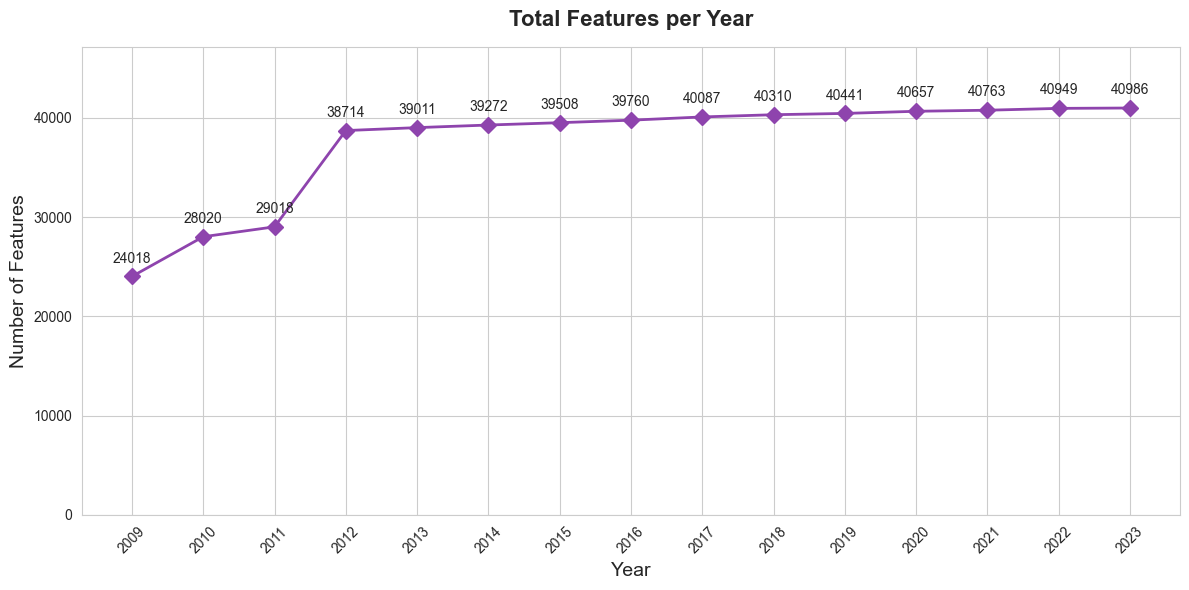

In [62]:
import seaborn as sns

# scan_parquet = lazy, only reads what's needed (very fast)
yearly_counts = (
    pl.scan_parquet('../data/raw/train.parquet')
    .with_columns(pl.col('day_utc').dt.year().alias('year'))
    .group_by('year')
    .agg(pl.col('metric').n_unique().alias('num_vars'))
    .sort('year')
    .collect()  # execute here
)
years  = yearly_counts['year'].to_list()
counts = yearly_counts['num_vars'].to_list()

# plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
plt.plot(years, counts, marker='D', color='#8e44ad', linewidth=2, markersize=8)
plt.title('Total Features per Year', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Features', fontsize=14)
plt.xticks(years, rotation=45)

for x, y in zip(years, counts):
    plt.annotate(f'{y}', (x, y), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=10)
plt.ylim(bottom=0, top=max(counts) * 1.15)
plt.tight_layout()
plt.show()

# Mining Pool Dendogram and VIF 

In [ ]:
full_mining_family = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.contains("pool"))
    .collect()
)
len(full_mining_family)
full_mining_df = full_mining_family.to_pandas()

In [ ]:
full_mining_df = full_mining_df.pivot(columns='metric',index='day_utc', values='value')
len(full_mining_df.columns)

In [ ]:
X = (
    full_mining_df
    .select_dtypes(include='number')
    .replace([np.inf, -np.inf], np.nan)
)
X = X.fillna(X.median())
X = X.loc[:, X.nunique() > 1]

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    index=X.index,
    columns=X.columns
)

In [ ]:
Z = linkage(X_scaled.T, method="ward", metric="euclidean")

fig = plt.figure(figsize=(16, 6))
dendrogram(
    Z,
    no_labels=True
)

plt.tight_layout()
fig.suptitle("Dendogram of mining pool columns")
plt.show()

In [ ]:
clusters_mining_pool = fcluster(Z, t=300, criterion="distance")

cluster_map_mining_pool = dict(zip(X_scaled.columns, clusters_mining_pool))


cluster_df_mining_pool = pd.DataFrame({
    "feature": X_scaled.columns,
    "cluster": clusters_mining_pool
})
cluster_df_mining_pool.head()

In [ ]:
cluster_df_mining_pool["cluster"].value_counts().sort_index()

In [ ]:
n = cluster_df_mining_pool["cluster"].nunique()
clusters_mining_pool_dict = {}
for i in range(1, n+1):
    clusters_mining_pool_dict[i] = cluster_df_mining_pool[cluster_df_mining_pool["cluster"] == i]["feature"].tolist()


high_vif_mining_pool = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters_mining_pool_dict[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif_mining_pool[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif_mining_pool[i]}")

In [ ]:
all_high_vif_mining_pool = [col for cols in high_vif_mining_pool.values() for col in cols]
len(all_high_vif_mining_pool)

In [ ]:
columns_to_drop_dict = {
    "columns_to_drop": all_high_vif_dca + all_high_vif_addrs + all_high_vif_cost_basis + all_high_vif_price + all_high_vif_mining_pool
}
columns_to_drop = pd.DataFrame(columns_to_drop_dict)
columns_to_drop.to_csv("../columns_to_drop.csv", index=False)

### Checking the bitcoin crash 

In [38]:
some_cols = ["active_price","price_200d_sma","price_200d_sma_ratio_2y_sma","price_21d_ema","price_21d_ema_ratio_1y_0sd_usd","price_200d_ema","price_200d_ema_ratio","price_200d_ema_ratio_2y_0sd_usd"]

In [39]:
crash_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(
        (pl.col("day_utc") >= pl.date(2017, 1, 1)) & 
        ((pl.col("day_utc") <= pl.date(2018, 12, 31)))
    )
    .filter(pl.col("metric").is_in(["active_price","price_200d_sma","price_200d_sma_ratio_2y_sma","price_21d_ema","price_21d_ema_ratio_1y_0sd_usd","price_200d_ema","price_200d_ema_ratio_2y_0sd_usd", "price_21d_sma"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [ ]:
fig_price = px.line(crash_df.to_pandas(), x='day_utc', y='value', color='metric', title='Price Metrics During Crash Period',facet_col="metric", facet_col_wrap=4)
fig_price.update_yaxes(matches=None)
fig_price.show()
# add in renderer="browser" in .show() if package version mismatch

### Market cap plot

In [42]:
cap_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(["market_cap"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

cap_ratio_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(["active_price","market_cap_growth_rate"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [43]:
px.line(cap_df.to_pandas(), x='day_utc', y='value', color='metric', title='Market Cap evolution over time')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'metric=market_cap<br>day_utc=%{x}<br>value=%{y}<extra></extra>',
              'legendgroup': 'market_cap',
              'line': {'color': '#636efa', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines',
              'name': 'market_cap',
              'showlegend': True,
              'type': 'scattergl',
              'x': array(['2009-01-03T00:00:00.000', '2009-01-09T00:00:00.000',
                          '2009-01-10T00:00:00.000', ..., '2023-12-29T00:00:00.000',
                          '2023-12-30T00:00:00.000', '2023-12-31T00:00:00.000'],
                         shape=(5471,), dtype='datetime64[ms]'),
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'g662dCCo+AbIcOaEKaad0+oBRoQg=='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'legend': {'title': {'text': 'metric'}, 'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Market Cap evolution over time'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'day_utc'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'value'}}}
})

In [44]:
px.line(cap_ratio_df.to_pandas(), x='day_utc', y='value', color='metric', title='Cap Ratio Metrics During Crash Period',facet_col="metric", facet_col_wrap=2)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'metric=active_price<br>day_utc=%{x}<br>value=%{y}<extra></extra>',
              'legendgroup': 'active_price',
              'line': {'color': '#636efa', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines',
              'name': 'active_price',
              'showlegend': True,
              'type': 'scattergl',
              'x': array(['2009-01-09T00:00:00.000', '2009-01-10T00:00:00.000',
                          '2009-01-11T00:00:00.000', ..., '2023-12-29T00:00:00.000',
                          '2023-12-30T00:00:00.000', '2023-12-31T00:00:00.000'],
                         shape=(5470,), dtype='datetime64[ms]'),
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'rWTGTJQGcYItGfZ8lAzCwoj6xqyUA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'hovertemplate': 'metric=market_cap_growth_rate<br>day_utc=%{x}<br>value=%{y}<extra></extra>',
              'legendgroup': 'market_cap_growth_rate',
              'line': {'color': '#EF553B', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines',
              'name': 'market_cap_growth_rate',
              'showlegend': True,
              'type': 'scattergl',
              'x': array(['2011-08-16T00:00:00.000', '2011-08-17T00:00:00.000',
                          '2011-08-18T00:00:00.000', ..., '2023-12-29T00:00:00.000',
                          '2023-12-30T00:00:00.000', '2023-12-31T00:00:00.000'],
                         shape=(4521,), dtype='datetime64[ms]'),
              'xaxis': 'x2',
              'y': {'bdata': ('ZmZmZu7v4EB3vp8aL43cQJHtfD8dld' ... 'rMlxeZY0ASpb3BF9ZjQAu1pnnHCWRA'),
                    'dtype': 'f8'},
              'yaxis': 'y2'}],
    'layout': {'annotations': [{'font': {},
                                'showarrow': False,
                                'text': 'metric=active_price',
                                'x': 0.245,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'},
                               {'font': {},
                                'showarrow': False,
                                'text': 'metric=market_cap_growth_rate',
                                'x': 0.755,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'}],
               'legend': {'title': {'text': 'metric'}, 'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Cap Ratio Metrics During Crash Period'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 0.49], 'title': {'text': 'day_utc'}},
               'xaxis2': {'anchor': 'y2', 'domain': [0.51, 1.0], 'matches': 'x', 'title': {'text': 'day_utc'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'value'}},
               'yaxis2': {'anchor': 'x2', 'domain': [0.0, 1.0], 'matches': 'y', 'showticklabels': False}}
})

In [ ]:
rel_ratio_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(["realized_cap_rel_to_own_market_cap","net_unrealized_pnl_rel_to_market_cap"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [ ]:
fig_rel = px.line(rel_ratio_df.to_pandas(), x='day_utc', y='value', color='metric', title='Realized Cap Ratio Metrics During Crash Period',facet_col="metric", facet_col_wrap=4)
fig_rel.update_yaxes(matches=None)
fig_rel.show()

### PNL plots

In [ ]:
pnl_cols = ["net_unrealized_pnl_rel_to_market_cap","net_unrealized_pnl"]
pnl_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(pnl_cols))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [ ]:
fig_pnl = px.line(pnl_df.to_pandas(), x='day_utc', y='value', color='metric', title='Net Unrealized PnL Metrics During Crash Period',facet_col="metric", facet_col_wrap=4)
fig_pnl.update_yaxes(matches=None)
fig_pnl.show()